# EDA NOTEBOOK

In [3]:
!pip install  emoji langcodes language_data squarify

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.1/183.1 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 98.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 64.9 MB/s eta 0:00:00


In [73]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import udf
from pyspark.sql.types import  StringType, IntegerType,BooleanType,LongType,ArrayType
from pyspark.sql.functions import col, trim, split, explode, regexp_replace,when, sum, round, log2, to_timestamp,array_contains, concat_ws, isnan ,expr,avg,desc,count,max,date_trunc, regexp_extract,year
import emoji
import seaborn as sns
import matplotlib.pyplot as plt
import unicodedata
import pandas as pd
import langcodes
import plotly.express as px
import numpy as np


# Streams data
[link text](https://)

In [5]:
spark=SparkSession.builder.appName('Client_Driver').getOrCreate()

In [34]:
streams_df= df = spark.read .option("header", "true").option("quote", '"') .option("escape", '"') .option("multiLine", "true") .csv("streams.csv")

In [ ]:
streams_df.cache()

DataFrame[id: string, user_id: string, user_login: string, user_name: string, game_id: string, game_name: string, type: string, title: string, viewer_count: string, started_at: string, language: string, thumbnail_url: string, tag_ids: string, tags: string, is_mature: string]

In [ ]:
streams_df.show(5)

+------------+----------+------------+------------+-------+-------------+----+--------------------+------------+--------------------+--------+--------------------+-------+--------------------+---------+
|          id|   user_id|  user_login|   user_name|game_id|    game_name|type|               title|viewer_count|          started_at|language|       thumbnail_url|tag_ids|                tags|is_mature|
+------------+----------+------------+------------+-------+-------------+----+--------------------+------------+--------------------+--------+--------------------+-------+--------------------+---------+
|316985010917| 238813810|    eliasn97|    eliasn97| 509658|Just Chatting|live|Anton Vlog Reacti...|       23930|2026-04-16T17:04:41Z|      de|https://static-cd...|     []| ['Deutsch', 'GOTY']|    False|
|318801858650|1019733647|      marlon|      Marlon| 509658|Just Chatting|live|🇬🇧 NANDO'S WITH...|       11444|2026-04-16T14:29:43Z|      en|https://static-cd...|     []|         ['English'

In [ ]:
streams_df.printSchema()

root
 |-- id: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- user_login: string (nullable = true)
 |-- user_name: string (nullable = true)
 |-- game_id: string (nullable = true)
 |-- game_name: string (nullable = true)
 |-- type: string (nullable = true)
 |-- title: string (nullable = true)
 |-- viewer_count: string (nullable = true)
 |-- started_at: string (nullable = true)
 |-- language: string (nullable = true)
 |-- thumbnail_url: string (nullable = true)
 |-- tag_ids: string (nullable = true)
 |-- tags: string (nullable = true)
 |-- is_mature: string (nullable = true)



In [ ]:
streams_df = streams_df.drop("thumbnail_url")

In [ ]:
streams_df.show(5)


+------------+----------+------------+------------+-------+-------------+----+--------------------+------------+--------------------+--------+-------+--------------------+---------+
|          id|   user_id|  user_login|   user_name|game_id|    game_name|type|               title|viewer_count|          started_at|language|tag_ids|                tags|is_mature|
+------------+----------+------------+------------+-------+-------------+----+--------------------+------------+--------------------+--------+-------+--------------------+---------+
|316985010917| 238813810|    eliasn97|    eliasn97| 509658|Just Chatting|live|Anton Vlog Reacti...|       23930|2026-04-16T17:04:41Z|      de|     []| ['Deutsch', 'GOTY']|    False|
|318801858650|1019733647|      marlon|      Marlon| 509658|Just Chatting|live|🇬🇧 NANDO'S WITH...|       11444|2026-04-16T14:29:43Z|      en|     []|         ['English']|    False|
|316377044855| 204730616|       cinna|       Cinna| 509658|Just Chatting|live|EXPLORING LOND

In [ ]:
print('shape:',streams_df.count(),",", len(streams_df.columns))

shape: 81509 , 14


In [ ]:
string_cols = ["id", "user_id", "user_login", "user_name", "game_id", "game_name", "type"
, "title", "started_at", "language", "tag_ids", "tags"]

for col_name in string_cols:
    streams_df = streams_df.withColumn(col_name, trim(col(col_name)))

In [ ]:
streams_df = streams_df.withColumn("viewer_count", col("viewer_count").cast(IntegerType()))

streams_df = streams_df.withColumn("viewer_count", col("viewer_count").cast(LongType()))

streams_df = streams_df.withColumn("is_mature", col("is_mature").cast(BooleanType()))

streams_df = streams_df.withColumn("started_at", to_timestamp(col("started_at")))

In [ ]:
print('null count per column')
streams_df.select([sum(when(col(column).isNull(), 1).otherwise(0)).alias(column) for column in streams_df.columns]).show()
print('null % per column')
streams_df.select([round(sum(when(col(c).isNull(), 1).otherwise(0)) / streams_df.count() * 100, 5).alias(c) for c in streams_df.columns]).show()

null count per column
+---+-------+----------+---------+-------+---------+----+-----+------------+----------+--------+-------+----+---------+
| id|user_id|user_login|user_name|game_id|game_name|type|title|viewer_count|started_at|language|tag_ids|tags|is_mature|
+---+-------+----------+---------+-------+---------+----+-----+------------+----------+--------+-------+----+---------+
|  0|      0|         0|        0|      0|        5|   0|  319|           0|         0|       0|      0|  65|        0|
+---+-------+----------+---------+-------+---------+----+-----+------------+----------+--------+-------+----+---------+

null % per column
+---+-------+----------+---------+-------+---------+----+-------+------------+----------+--------+-------+-------+---------+
| id|user_id|user_login|user_name|game_id|game_name|type|  title|viewer_count|started_at|language|tag_ids|   tags|is_mature|
+---+-------+----------+---------+-------+---------+----+-------+------------+----------+--------+-------+---

In [ ]:
print( 'number of unique ids', streams_df.select('id').distinct().count())

number of unique ids 81509


In [ ]:
print('Duplicates Count ', streams_df.count() - streams_df.dropDuplicates().count())

Duplicates Count  0


In [ ]:
stream_df=streams_df.dropna()

In [ ]:
streams_df.select('tag_ids').distinct().show(truncate=False)

+-------+
|tag_ids|
+-------+
|[]     |
+-------+



In [ ]:
streams_df.select('tags').distinct().show()

+--------------------+
|                tags|
+--------------------+
|['English', 'Tina...|
|['Русский', 'Виту...|
|['Русский', 'кера...|
|['Latina', 'latin...|
|['Español', 'girl...|
|['ecriture', 'aut...|
|['yugioh', 'mdpro...|
|['Русский', 'обще...|
|  ['日本語', '雑談']|
|['English', 'Puzz...|
|['dojo', 'shaolin...|
|['Deutsch', 'Engl...|
|['Português', 'AM...|
|['English', 'Vari...|
|['Français', 'NAS...|
|['English', 'come...|
|['roleplay', 'str...|
|['Português', 'GT...|
|['Português', 'Fo...|
|['Русский', 'пода...|
+--------------------+
only showing top 20 rows


In [ ]:
streams_df = streams_df.withColumn("tags",split(regexp_replace(regexp_replace(col("tags"), r"[\[\]]", ""),r"'", ""), ", "))

In [ ]:
stream_tags_df = streams_df.select(col("id").alias("stream_id"),explode(col("tags")).alias("tag"))

In [ ]:
streams_df = streams_df.drop("tags", "tag_ids")

In [ ]:
streams_df.select("language").distinct()

DataFrame[language: string]

In [ ]:
streams_df.select(col("title")).show()

+--------------------+
|               title|
+--------------------+
|Anton Vlog Reacti...|
|🇬🇧 NANDO'S WITH...|
|EXPLORING LONDON ...|
|⚽️ IM IN LONDON ⚽...|
|НОВЫЙ КОМП - НОВЫ...|
|THICK BELLY THURS...|
|i will find out w...|
|QSMP 2 / Día 23: ...|
|   ЛИСТАЕМ ТИКИТОКИ!|
|🚨 Iran War BLOCK...|
|Смотрим "хантер х...|
|🌸 NICO ROBIN COS...|
|               Lemon|
|67 | БРАЗИЛИЯ 19 ...|
|MAKING STREAMER I...|
|ура КРІНЖА з МАТЮ...|
|🧠 [1440p] СМОТРИ...|
|I GET TO DRIVE MY...|
|HOLA AMIGUITAS - ...|
|IRL - 🥊 AULA DE ...|
+--------------------+
only showing top 20 rows


In [35]:
clean_title_udf = udf(lambda text: "".join(ch for ch in emoji.replace_emoji(text, replace='') if not unicodedata.category(ch).startswith('P')).strip() if text else None, StringType())
streams_df = streams_df.withColumn("title", trim(clean_title_udf(col("title"))))

In [ ]:
streams_df.select(col("title")).show()

+--------------------+
|               title|
+--------------------+
|Anton Vlog Reacti...|
|NANDOS WITH AB AN...|
|EXPLORING LONDON ...|
|IM IN LONDON  TRA...|
| НОВЫЙ КОМП  НОВЫЙ Я|
|THICK BELLY THURS...|
|i will find out w...|
|QSMP 2  Día 23 Ju...|
|    ЛИСТАЕМ ТИКИТОКИ|
|Iran War BLOCKADE...|
|Смотрим хантер х ...|
|NICO ROBIN COSPLA...|
|               Lemon|
|67 | БРАЗИЛИЯ 19 ...|
|MAKING STREAMER I...|
|ура КРІНЖА з МАТЮ...|
|1440p СМОТРИМ БЕР...|
|I GET TO DRIVE MY...|
|HOLA AMIGUITAS  M...|
|IRL   AULA DE BOX...|
+--------------------+
only showing top 20 rows


In [36]:
def get_lang_name(code):
    if not code: return None
    try:
        return langcodes.Language.get(code).display_name()
    except:
        return code

lang_name_udf = udf(get_lang_name, StringType())

In [ ]:
streams_df = streams_df.withColumn("language", lang_name_udf(col("language")))

In [ ]:
print('Number of languages: ', streams_df.select("language").distinct().count())

Number of languages:  35


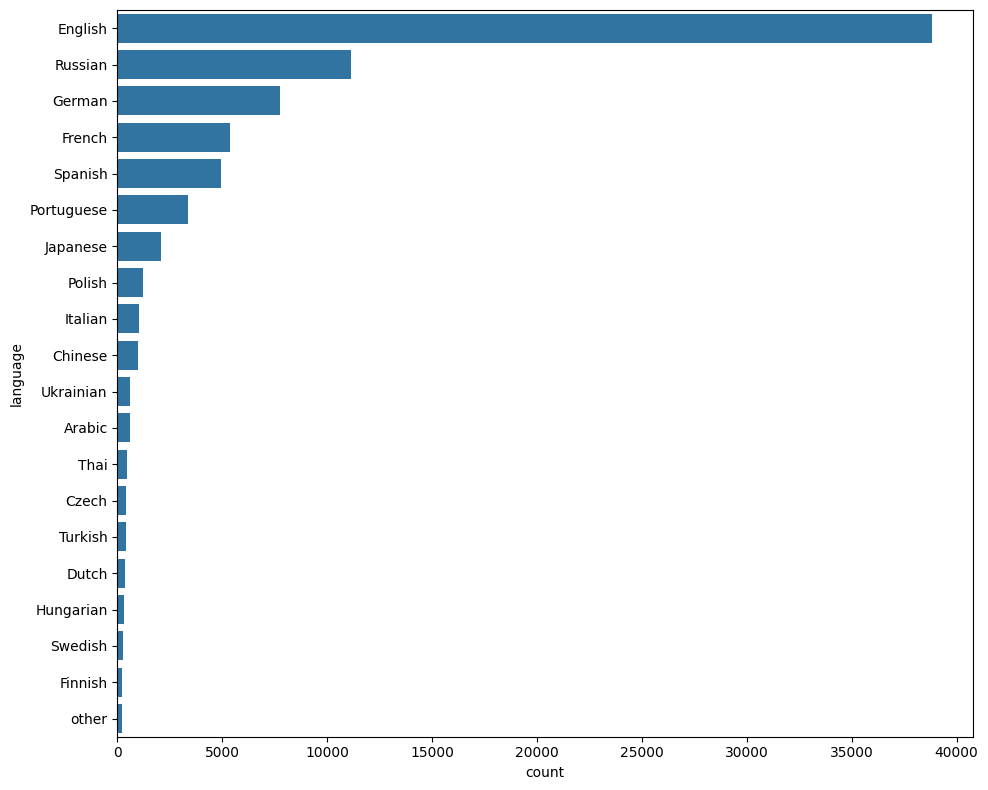

In [ ]:
lang_df = streams_df.groupBy("language").count().orderBy("count", ascending=False).limit(20).toPandas()

plt.figure(figsize=(10, 8))
sns.barplot(data=lang_df, x="count", y="language")
plt.tight_layout()
plt.show()

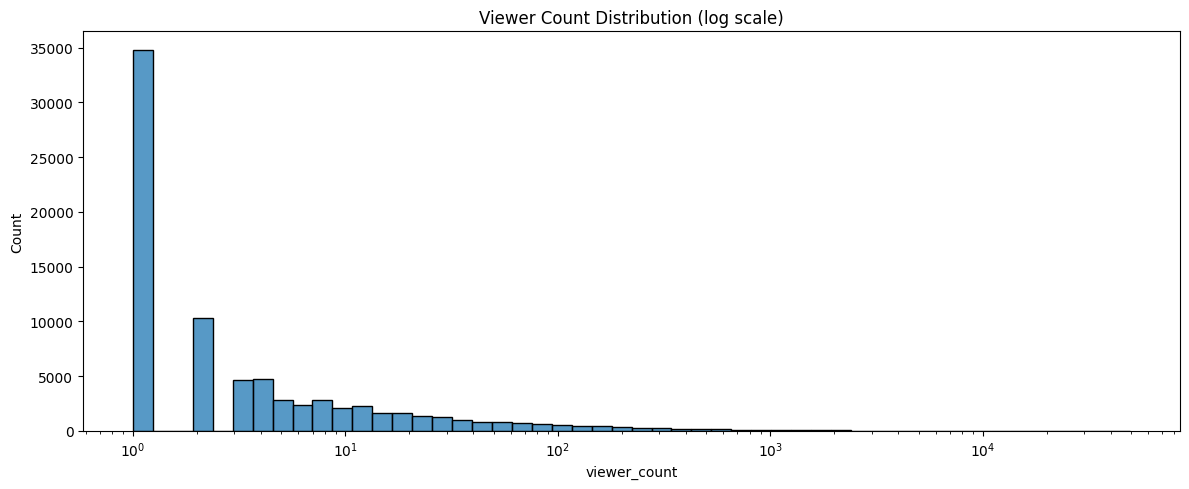

In [ ]:
viewer_df = streams_df.select("viewer_count").toPandas()

plt.figure(figsize=(12, 5))
sns.histplot(data=viewer_df, x="viewer_count", bins=50, log_scale=True)
plt.title("Viewer Count Distribution (log scale)")
plt.tight_layout()
plt.show()

In [ ]:
streams_df.unpersist()
streams_df.select("viewer_count").summary().show()

+-------+------------------+
|summary|      viewer_count|
+-------+------------------+
|  count|             81509|
|   mean|33.218748849820265|
| stddev|377.75209016851744|
|    min|                 0|
|    25%|                 1|
|    50%|                 2|
|    75%|                 7|
|    max|             49491|
+-------+------------------+



In [ ]:
mature_df = streams_df.groupBy("is_mature").count().toPandas()
mature_df["is_mature"] = mature_df["is_mature"].map({True: "Adult", False: "Child-friendly"})

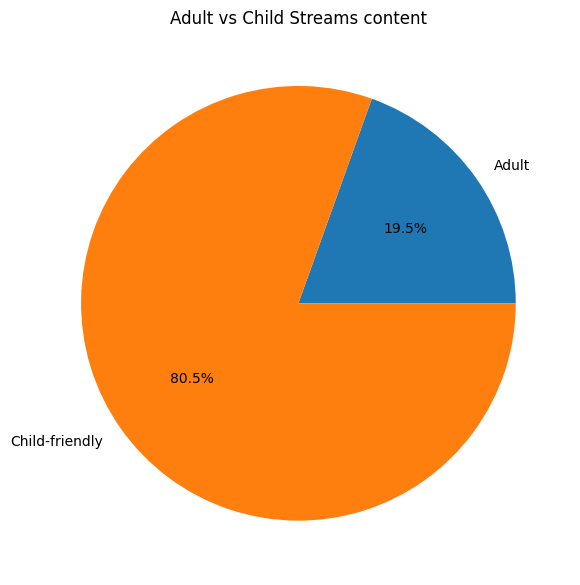

In [ ]:
plt.figure(figsize=(6, 6))
plt.pie(mature_df["count"], labels=mature_df["is_mature"], autopct="%1.1f%%")
plt.title("Adult vs Child Streams content")
plt.tight_layout()
plt.show()


In [ ]:
game_df = streams_df.groupBy("game_name").count().orderBy("count", ascending=False).limit(20).toPandas()
fig = px.treemap(game_df,path=["game_name"],values="count",title="Game Popularity by Stream Count",color="count",color_continuous_scale="Blues")
fig.update_traces(textinfo="label+value")
fig.update_layout(margin=dict(t=50, l=10, r=10, b=10))
fig.show()

In [ ]:
game_mature_df = streams_df.filter(col("is_mature") == True).groupBy("game_name").count() .orderBy("count", ascending=False) .limit(15).toPandas()

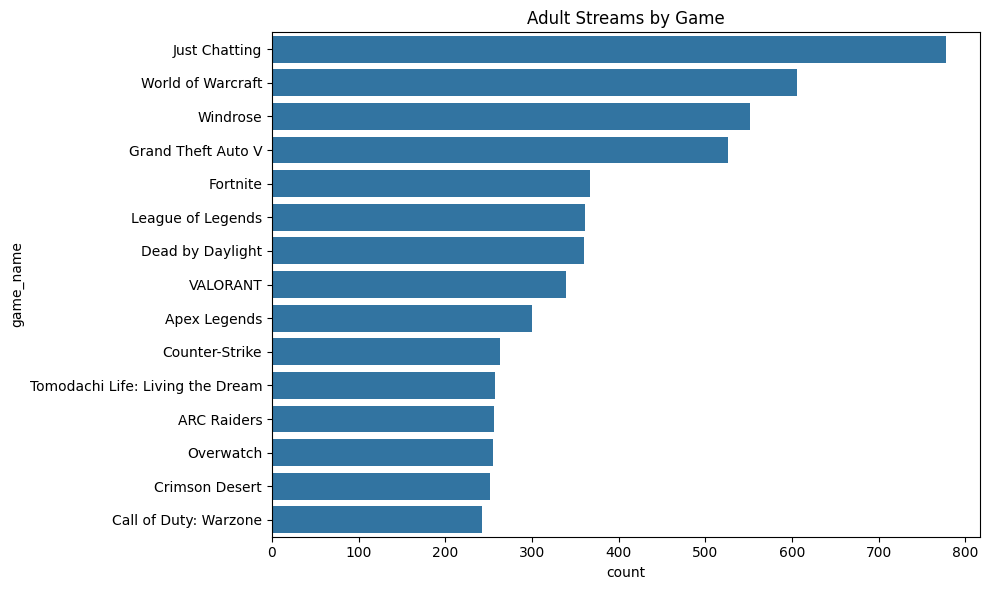

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=game_mature_df, x="count", y="game_name")
plt.title("Adult Streams by Game")
plt.tight_layout()
plt.show()

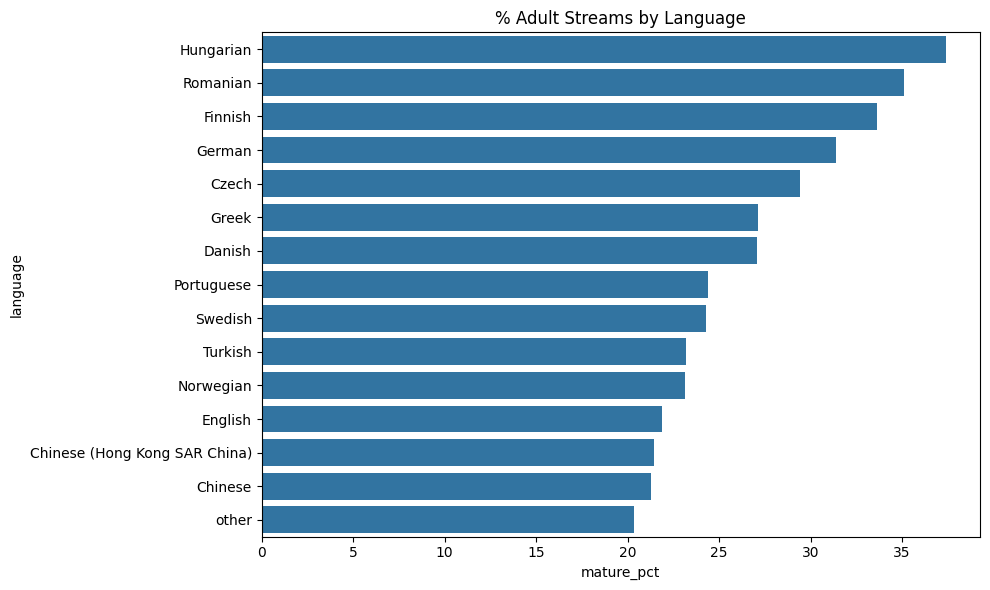

In [ ]:
total_df = streams_df.groupBy("language").count().withColumnRenamed("count", "total")
mature_df2 = streams_df.filter(col("is_mature") == True).groupBy("language").count().withColumnRenamed("count", "mature_count")

result = total_df.join(mature_df2, "language") \
    .withColumn("mature_pct", col("mature_count") / col("total") * 100) \
    .orderBy("mature_pct", ascending=False) \
    .limit(15).toPandas()

plt.figure(figsize=(10, 6))
sns.barplot(data=result, x="mature_pct", y="language")
plt.title("% Adult Streams by Language")
plt.tight_layout()
plt.show()

In [ ]:
streams_df.unpersist()

DataFrame[id: string, user_id: string, user_login: string, user_name: string, game_id: string, game_name: string, type: string, title: string, viewer_count: bigint, started_at: timestamp, language: string, is_mature: boolean]

# Clips data



In [ ]:
clips_df=spark.read.option("header", "true").option("quote", '"') .option("escape", '"') .option("multiLine", "true") .csv("clips.csv")

In [ ]:
clips_df.cache()

DataFrame[id: string, url: string, embed_url: string, broadcaster_id: string, broadcaster_name: string, creator_id: string, creator_name: string, video_id: string, game_id: string, language: string, title: string, view_count: string, created_at: string, thumbnail_url: string, duration: string, vod_offset: string, is_featured: string]

In [ ]:
clips_df.printSchema()

root
 |-- id: string (nullable = true)
 |-- url: string (nullable = true)
 |-- embed_url: string (nullable = true)
 |-- broadcaster_id: string (nullable = true)
 |-- broadcaster_name: string (nullable = true)
 |-- creator_id: string (nullable = true)
 |-- creator_name: string (nullable = true)
 |-- video_id: string (nullable = true)
 |-- game_id: string (nullable = true)
 |-- language: string (nullable = true)
 |-- title: string (nullable = true)
 |-- view_count: string (nullable = true)
 |-- created_at: string (nullable = true)
 |-- thumbnail_url: string (nullable = true)
 |-- duration: string (nullable = true)
 |-- vod_offset: string (nullable = true)
 |-- is_featured: string (nullable = true)



In [ ]:
clips_df=clips_df.drop('thumbnail_url','embed_url','url')

In [ ]:
clips_df = clips_df.withColumn("view_count", trim(col("view_count")).cast("long")).withColumn("created_at", to_timestamp(col("created_at"))).withColumn("duration", trim(col("duration")).cast("float")).withColumn("vod_offset", trim(col("vod_offset")).cast('float').cast("integer")) \
.withColumn("is_featured", trim(col("is_featured")).cast("boolean"))

In [ ]:
clips_df = clips_df.withColumn(
    "vod_offset",
    expr("try_cast(vod_offset as double)")
)

In [ ]:
clips_df.show(5)

+--------------------+--------------+----------------+----------+-------------+--------+-------+--------+--------------------+----------+-------------------+--------+----------+-----------+
|                  id|broadcaster_id|broadcaster_name|creator_id| creator_name|video_id|game_id|language|               title|view_count|         created_at|duration|vod_offset|is_featured|
+--------------------+--------------+----------------+----------+-------------+--------+-------+--------+--------------------+----------+-------------------+--------+----------+-----------+
|ObliviousObservan...|     174267851|      SilvaNo4ka| 415396165|   GutS22Leon|    NULL| 509658|      ru|              696969|   5773816|2020-12-10 03:13:11|    30.4|      NULL|      false|
|IronicArtisticOrc...|     122125654|          Brittt|  27477483|    Sunglasse|    NULL| 509658|      en|       OGRE LOUNGING|   5099543|2021-03-15 03:30:59|    14.9|      NULL|       true|
|AverageSparklyTor...|      61841555|   JesseDStre

In [ ]:
clips_df.dtypes

[('id', 'string'),
 ('broadcaster_id', 'string'),
 ('broadcaster_name', 'string'),
 ('creator_id', 'string'),
 ('creator_name', 'string'),
 ('video_id', 'string'),
 ('game_id', 'string'),
 ('language', 'string'),
 ('title', 'string'),
 ('view_count', 'bigint'),
 ('created_at', 'timestamp'),
 ('duration', 'float'),
 ('vod_offset', 'double'),
 ('is_featured', 'boolean')]

In [ ]:
string_cols = [c for c, t in clips_df.dtypes if t == "string"]

In [ ]:
for c in string_cols:
  clips_df = clips_df.withColumn(c, trim(col(c)))

In [ ]:
clips_df.select("duration").show(5)

+--------+
|duration|
+--------+
|    30.4|
|    14.9|
|    45.8|
|    17.4|
|    31.3|
+--------+
only showing top 5 rows


In [ ]:
clips_df.dtypes

[('id', 'string'),
 ('broadcaster_id', 'string'),
 ('broadcaster_name', 'string'),
 ('creator_id', 'string'),
 ('creator_name', 'string'),
 ('video_id', 'string'),
 ('game_id', 'string'),
 ('language', 'string'),
 ('title', 'string'),
 ('view_count', 'bigint'),
 ('created_at', 'timestamp'),
 ('duration', 'float'),
 ('vod_offset', 'double'),
 ('is_featured', 'boolean')]

In [ ]:
print('null count per column')
clips_df.select([sum(when(col(column).isNull(), 1).otherwise(0)).alias(column) for column in clips_df.columns]).show()

print('null % per column')
clips_df.select([round(sum(when(col(column).isNull(), 1).otherwise(0)) / clips_df.count() * 100, 3).alias(column) for column in clips_df.columns]).show()

null count per column
+---+--------------+----------------+----------+------------+--------+-------+--------+-----+----------+----------+--------+----------+-----------+
| id|broadcaster_id|broadcaster_name|creator_id|creator_name|video_id|game_id|language|title|view_count|created_at|duration|vod_offset|is_featured|
+---+--------------+----------------+----------+------------+--------+-------+--------+-----+----------+----------+--------+----------+-----------+
|  0|             0|              61|         0|         656|  424530|      0|     260|   41|         0|         0|       0|    424530|          0|
+---+--------------+----------------+----------+------------+--------+-------+--------+-----+----------+----------+--------+----------+-----------+

null % per column
+---+--------------+----------------+----------+------------+--------+-------+--------+-----+----------+----------+--------+----------+-----------+
| id|broadcaster_id|broadcaster_name|creator_id|creator_name|video_id|g

In [ ]:
clips_df=clips_df.drop('vod_offset','video_id')

In [ ]:
clips_df=clips_df.dropna()

In [ ]:
clips_df = clips_df.withColumn("title", trim(clean_title_udf(col("title"))))
clips_df = clips_df.withColumn("language", lang_name_udf(col("language")))

In [ ]:
clips_df.show(5)

+--------------------+--------------+----------------+----------+-------------+-------+--------------------+--------------------+----------+-------------------+--------+-----------+
|                  id|broadcaster_id|broadcaster_name|creator_id| creator_name|game_id|            language|               title|view_count|         created_at|duration|is_featured|
+--------------------+--------------+----------------+----------+-------------+-------+--------------------+--------------------+----------+-------------------+--------+-----------+
|ObliviousObservan...|     174267851|      SilvaNo4ka| 415396165|   GutS22Leon| 509658|             Russian|              696969|   5773816|2020-12-10 03:13:11|    30.4|      false|
|IronicArtisticOrc...|     122125654|          Brittt|  27477483|    Sunglasse| 509658|             English|       OGRE LOUNGING|   5099543|2021-03-15 03:30:59|    14.9|       true|
|AverageSparklyTor...|      61841555|   JesseDStreams|  29434083|     ZennieQT| 509658|   

In [ ]:
vc_pd = clips_df.select("view_count").dropna().toPandas()

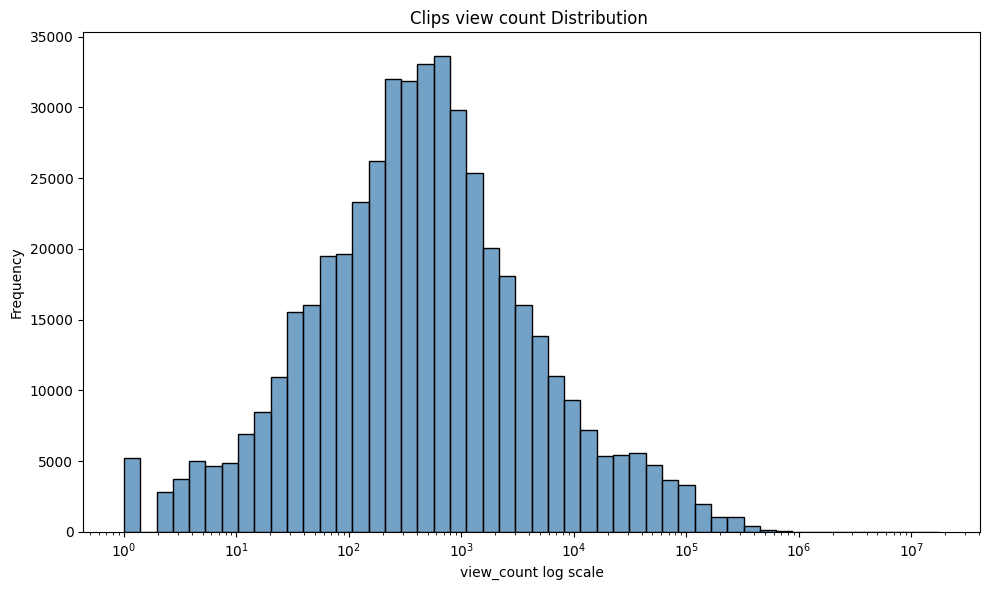

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=vc_pd, x="view_count", bins=50, log_scale=True, color="steelblue")
plt.title("Clips view count Distribution ")
plt.xlabel("view_count log scale")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
dur_pd = clips_df.select("duration").toPandas()

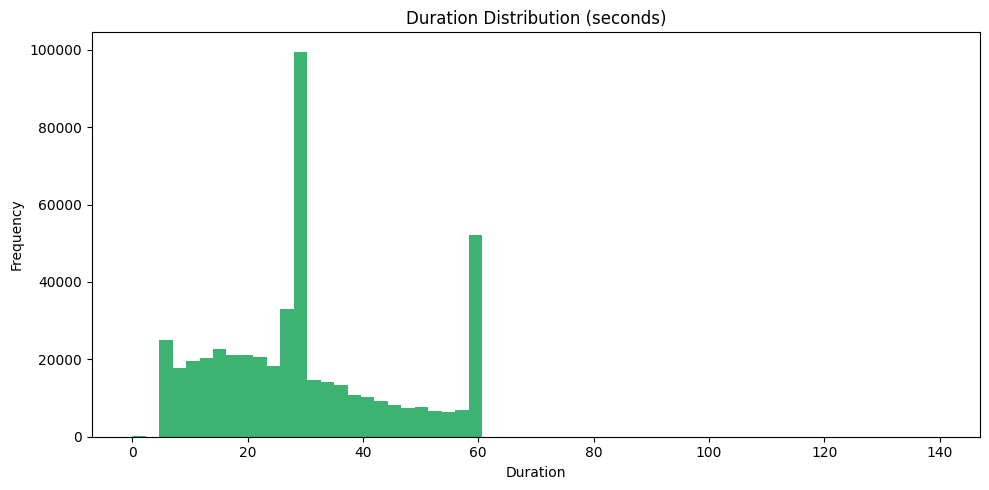

In [ ]:

plt.figure(figsize=(10, 5))
plt.hist(dur_pd["duration"], bins=60, color="mediumseagreen", edgecolor="none")
plt.title("Duration Distribution (seconds)")
plt.xlabel("Duration")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
clips_df.select("duration").summary().show()

+-------+------------------+
|summary|          duration|
+-------+------------------+
|  count|            486991|
|   mean|29.933054669607294|
| stddev| 15.75971412749754|
|    min|               0.0|
|    25%|              18.1|
|    50%|              29.3|
|    75%|              38.1|
|    max|             140.0|
+-------+------------------+



In [ ]:
# bootstrapping :) approx the pop mean
n_resamples = 200
means = []
for i in range(n_resamples):
    sample = clips_df.sample(withReplacement=True, fraction=1.0)
    mean_val = sample.select(avg("view_count")).collect()[0][0]
    means.append(mean_val)

means = np.array(means)

ci_low = np.percentile(means, 2.5)
ci_high = np.percentile(means, 97.5)

print(f"95% CI for Clips View Count: [{ci_low:,.2f}, {ci_high:,.2f}]")

95% CI for Clips View Count: [6,183.38, 6,454.33]


In [ ]:
clips_df.select(avg("view_count")).show()

+-----------------+
|  avg(view_count)|
+-----------------+
|6310.450724962063|
+-----------------+



In [ ]:
top_broadcasters = clips_df.groupBy("broadcaster_name").agg(sum("view_count").alias("total_views")).orderBy(desc("total_views")).limit(15).toPandas()


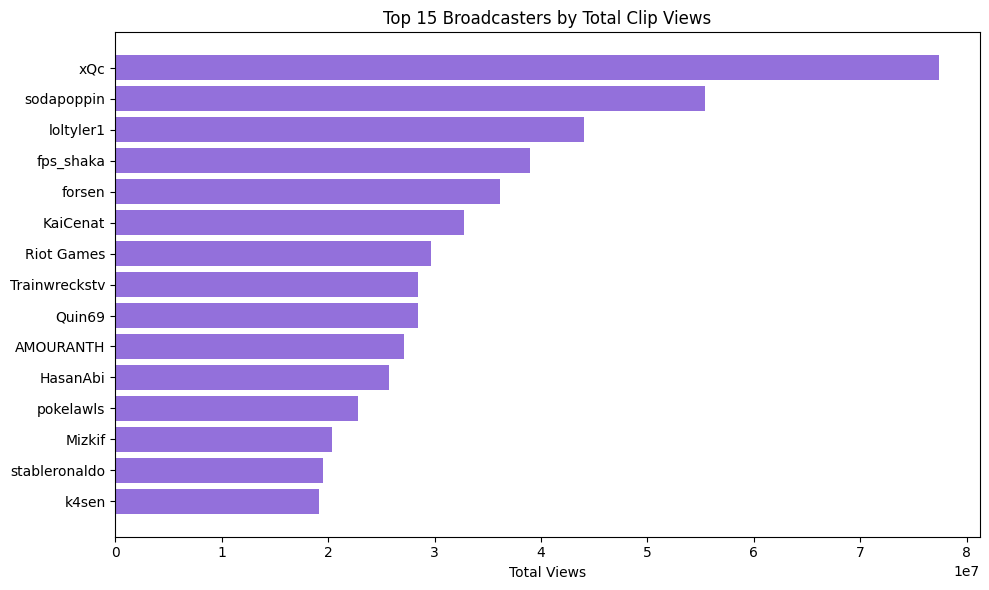

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(top_broadcasters["broadcaster_name"], top_broadcasters["total_views"], color="mediumpurple")
plt.gca().invert_yaxis()
plt.title("Top 15 Broadcasters by Total Clip Views")
plt.xlabel("Total Views")
plt.tight_layout()
plt.show()

In [ ]:
scatter_df = clips_df.select("duration", "view_count").toPandas()

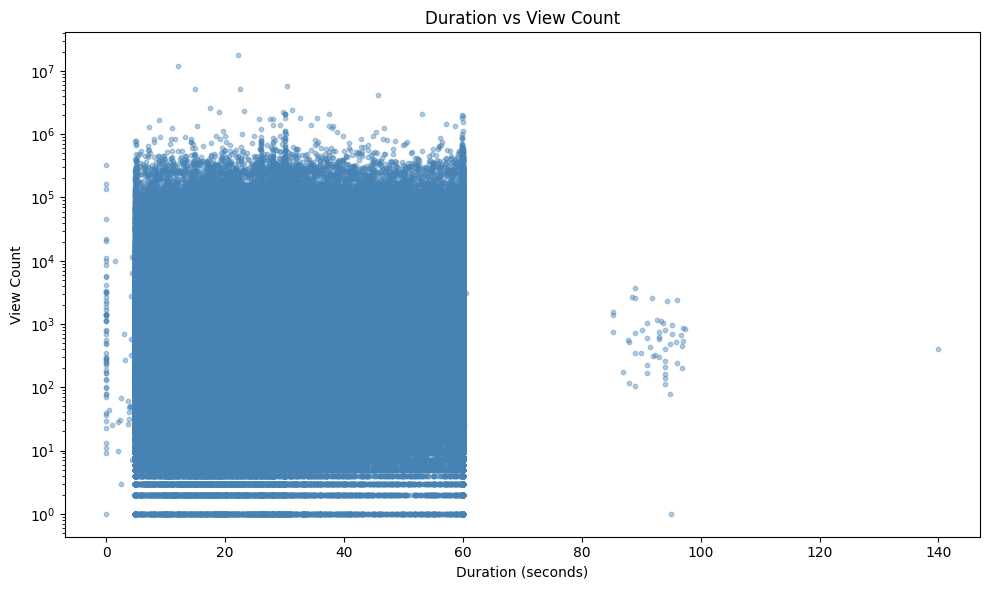

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(scatter_df["duration"], scatter_df["view_count"], alpha=0.4, color="steelblue", s=10)
plt.title("Duration vs View Count")
plt.yscale('log')
plt.xlabel("Duration (seconds)")
plt.ylabel("View Count")
plt.tight_layout()
plt.show()

In [ ]:

time_df = clips_df.withColumn("month", date_trunc("month", col("created_at"))).groupBy("month").count().orderBy("month").toPandas()


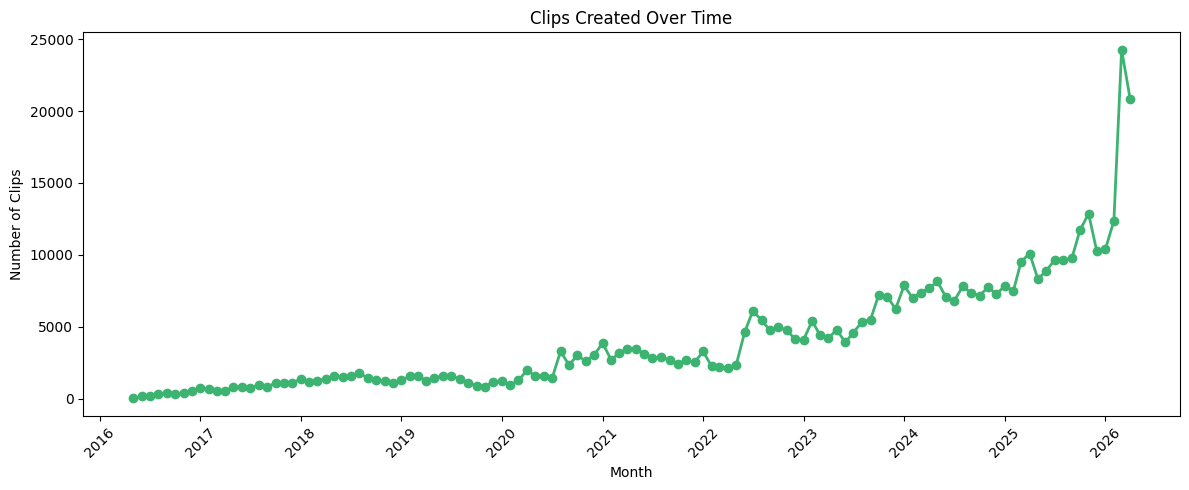

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(time_df["month"], time_df["count"], color="mediumseagreen", marker="o", linewidth=2)
plt.title("Clips Created Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Clips")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# videos data

In [12]:
videos_df=spark.read.option("header", "true").option("quote", '"') .option("escape", '"') .option("multiLine", "true") .csv("/content/videos.csv")

In [13]:
videos_df.cache()

DataFrame[id: string, stream_id: string, user_id: string, user_login: string, user_name: string, title: string, description: string, created_at: string, published_at: string, url: string, thumbnail_url: string, viewable: string, view_count: string, language: string, type: string, duration: string, muted_segments: string, game_id: string]

In [14]:
videos_df.show(5)

+----------+------------+----------+-----------+------------------+--------------------+-----------+--------------------+--------------------+--------------------+--------------------+--------+----------+--------+-------+--------+--------------+-------+
|        id|   stream_id|   user_id| user_login|         user_name|               title|description|          created_at|        published_at|                 url|       thumbnail_url|viewable|view_count|language|   type|duration|muted_segments|game_id|
+----------+------------+----------+-----------+------------------+--------------------+-----------+--------------------+--------------------+--------------------+--------------------+--------+----------+--------+-------+--------+--------------+-------+
|2750132435|316991360101| 736566543| foxyycsgo_|        foxyycsgo_|➡️ Bom diaa ➡️ A ...|       NULL|2026-04-17T09:34:05Z|2026-04-17T09:34:05Z|https://www.twitc...|https://vod-secur...|  public|         0|      pt|archive|      4s|        

In [21]:
videos_df.dtypes

[('id', 'string'),
 ('stream_id', 'string'),
 ('user_id', 'string'),
 ('user_login', 'string'),
 ('user_name', 'string'),
 ('title', 'string'),
 ('description', 'string'),
 ('created_at', 'string'),
 ('published_at', 'string'),
 ('url', 'string'),
 ('thumbnail_url', 'string'),
 ('viewable', 'string'),
 ('view_count', 'string'),
 ('language', 'string'),
 ('type', 'string'),
 ('duration', 'string'),
 ('muted_segments', 'string'),
 ('game_id', 'string')]

In [17]:
string_cols = [c for c, t in videos_df.dtypes if t == "string"]

In [18]:
for c in string_cols:
  videos_df = videos_df.withColumn(c, trim(col(c)))

In [19]:
print('null count per column')
videos_df.select([sum(when(col(column).isNull(), 1).otherwise(0)).alias(column) for column in   videos_df.columns]).show()
print('null % per column')
videos_df.select([round(sum(when(col(c).isNull(), 1).otherwise(0)) /   videos_df.count() * 100, 5).alias(c) for c in   videos_df.columns]).show()

null count per column
+---+---------+-------+----------+---------+-----+-----------+----------+------------+---+-------------+--------+----------+--------+----+--------+--------------+-------+
| id|stream_id|user_id|user_login|user_name|title|description|created_at|published_at|url|thumbnail_url|viewable|view_count|language|type|duration|muted_segments|game_id|
+---+---------+-------+----------+---------+-----+-----------+----------+------------+---+-------------+--------+----------+--------+----+--------+--------------+-------+
|  0|     2772|      0|         0|        0|   92|      57571|         0|           0|  0|            0|       1|         1|       1|   1|       1|         58030|      1|
+---+---------+-------+----------+---------+-----+-----------+----------+------------+---+-------------+--------+----------+--------+----+--------+--------------+-------+

null % per column
+---+---------+-------+----------+---------+-------+-----------+----------+------------+---+------------

In [60]:
print('Duplicates Count ', videos_df.count() -videos_df.dropDuplicates().count())

Duplicates Count  0


In [25]:
videos_df=videos_df.drop('description','muted_segments',  'url','thumbnail_url')

In [32]:
videos_df.select('duration').show(5)

+--------+
|duration|
+--------+
|       4|
|       5|
|       6|
|       9|
|       9|
+--------+
only showing top 5 rows


In [30]:
videos_df = videos_df.withColumn("view_count", col("view_count").cast("int")) .withColumn("created_at", to_timestamp(col("created_at"))).withColumn("published_at", to_timestamp(col("published_at"))).withColumn("duration",
    regexp_extract(col("duration"), r'(\d+)', 1).cast("int"))

In [42]:
videos_df.dtypes

[('id', 'string'),
 ('stream_id', 'string'),
 ('user_id', 'string'),
 ('user_login', 'string'),
 ('user_name', 'string'),
 ('title', 'string'),
 ('created_at', 'timestamp'),
 ('published_at', 'timestamp'),
 ('viewable', 'string'),
 ('view_count', 'int'),
 ('language', 'string'),
 ('type', 'string'),
 ('duration', 'int'),
 ('game_id', 'string')]

In [33]:
videos_df.select('duration').show(5)

+--------+
|duration|
+--------+
|       4|
|       5|
|       6|
|       9|
|       9|
+--------+
only showing top 5 rows


In [37]:
videos_df  = videos_df .withColumn("title", trim(clean_title_udf(col("title"))))
videos_df  = videos_df .withColumn("language", lang_name_udf(col("language")))

In [40]:
videos_df  = videos_df .dropna()

In [41]:
videos_df.select("title", "language").show(5)

+--------------------+----------+
|               title|  language|
+--------------------+----------+
|Bom diaa  A vossa...|Portuguese|
|      Бильярд турнир|   Russian|
|Hallo meine Wölfe...|    German|
|  弾き語りとおはなし|  Japanese|
|chill посиделки |...|   Russian|
+--------------------+----------+
only showing top 5 rows


In [45]:
durations = videos_df.select("duration").toPandas()["duration"]

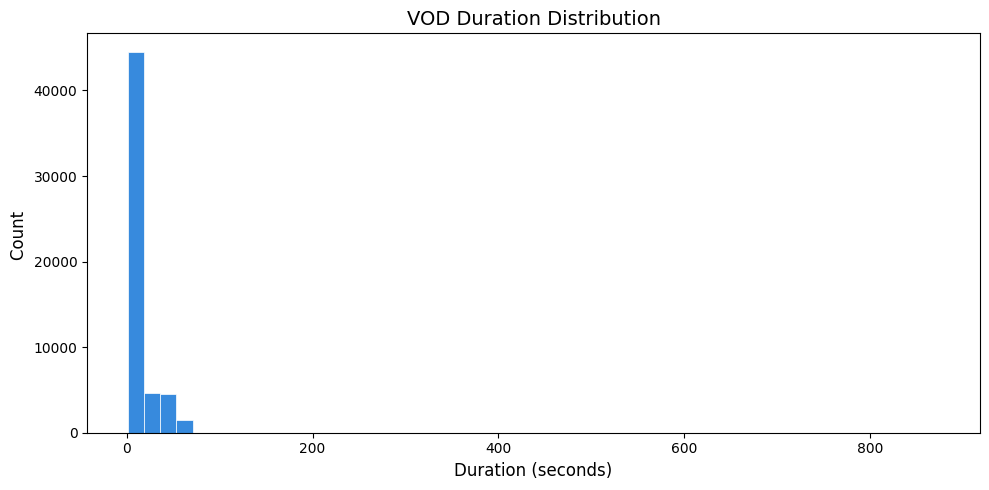

In [49]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(durations, bins=50, color="#378ADD", edgecolor="white", linewidth=0.5)
ax.set_xlabel("Duration (seconds)", fontsize=12)
ax.set_ylabel("Count ", fontsize=12)
ax.set_title("VOD Duration Distribution", fontsize=14)
plt.tight_layout()
plt.show()

In [51]:
views_pdf = videos_df.select("view_count").dropna().toPandas()
type_pdf = videos_df.groupBy("type").count().orderBy("count", ascending=False).toPandas()

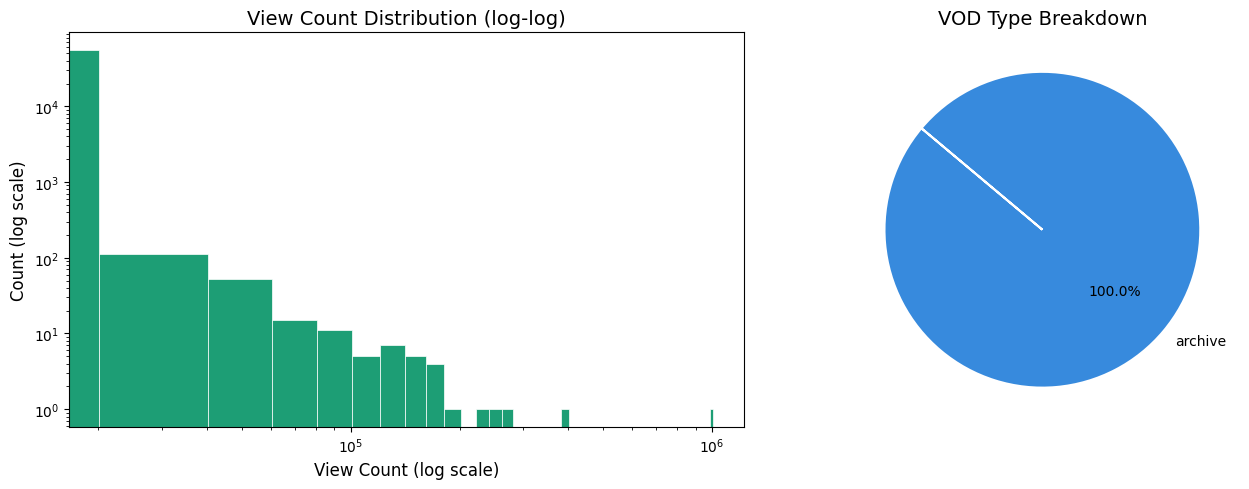

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(views_pdf["view_count"], bins=50, color="#1D9E75", edgecolor="white", linewidth=0.5)
axes[0].set_yscale("log")
axes[0].set_xscale("log")
axes[0].set_xlabel("View Count (log scale)", fontsize=12)
axes[0].set_ylabel("Count (log scale)", fontsize=12)
axes[0].set_title("View Count Distribution (log-log)", fontsize=14)

colors = ["#378ADD", "#1D9E75", "#D85A30", "#BA7517", "#993556"]
axes[1].pie(type_pdf["count"],labels=type_pdf["type"],autopct="%1.1f%%",colors=colors[:len(type_pdf)],startangle=140,wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[1].set_title("VOD Type Breakdown", fontsize=14)

plt.tight_layout()
plt.show()

In [57]:
time_pdf = videos_df.select("created_at", "published_at").dropna().toPandas()
time_pdf["created_at"] = pd.to_datetime(time_pdf["created_at"])
time_pdf["published_at"] = pd.to_datetime(time_pdf["published_at"])

/tmp/ipykernel_1911/2424276782.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  created_counts = time_pdf.groupby(time_pdf["created_at"].dt.floor("H")).size()
/tmp/ipykernel_1911/2424276782.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  published_counts = time_pdf.groupby(time_pdf["published_at"].dt.floor("H")).size()


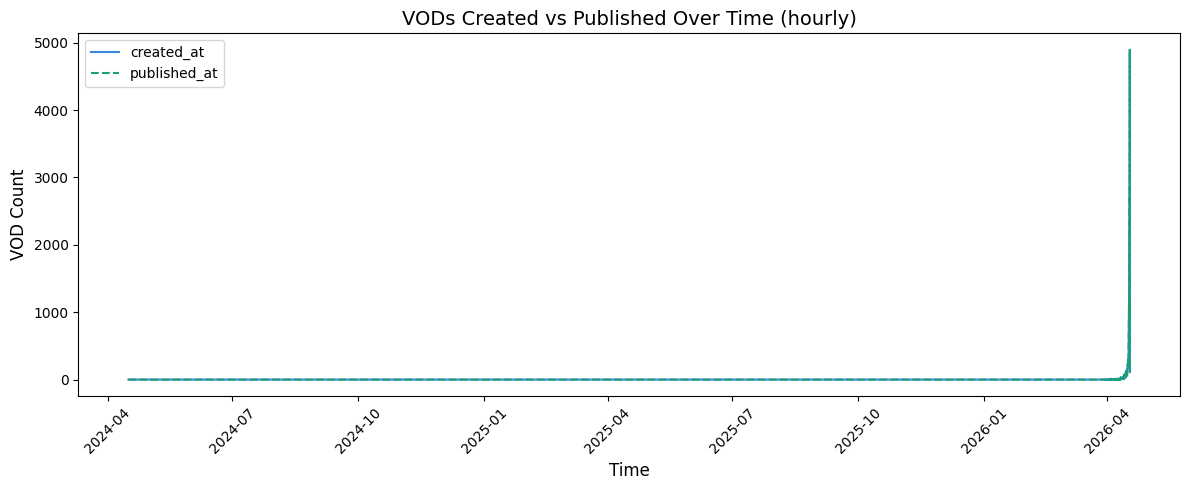

In [58]:
created_counts = time_pdf.groupby(time_pdf["created_at"].dt.floor("H")).size()
published_counts = time_pdf.groupby(time_pdf["published_at"].dt.floor("H")).size()
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(created_counts.index, created_counts.values, color="#378ADD", linewidth=1.5, label="created_at")
ax.plot(published_counts.index, published_counts.values, color="#1D9E75", linewidth=1.5, linestyle="--", label="published_at")
ax.set_xlabel("Time", fontsize=12)
ax.set_ylabel("VOD Count", fontsize=12)
ax.set_title("VODs Created vs Published Over Time (hourly)", fontsize=14)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [69]:
videos_df.unpersist()

DataFrame[id: string, stream_id: string, user_id: string, user_login: string, user_name: string, title: string, created_at: timestamp, published_at: timestamp, viewable: string, view_count: int, language: string, type: string, duration: int, game_id: string]

# users

In [61]:
users_df=spark.read.option("header", "true").option("quote", '"') .option("escape", '"') .option("multiLine", "true") .csv("/content/users.csv")

In [70]:
users_df.cache()

DataFrame[id: string, login: string, display_name: string, type: string, broadcaster_type: string, description: string, profile_image_url: string, offline_image_url: string, view_count: string, created_at: string]

In [62]:
users_df.show(5)

+---------+------------+------------+----+----------------+--------------------+--------------------+--------------------+----------+--------------------+
|       id|       login|display_name|type|broadcaster_type|         description|   profile_image_url|   offline_image_url|view_count|          created_at|
+---------+------------+------------+----+----------------+--------------------+--------------------+--------------------+----------+--------------------+
|238813810|    eliasn97|    eliasn97|NULL|         partner|GOTY 2021, 2022, ...|https://static-cd...|                NULL|         0|2018-07-15T12:43:44Z|
|204730616|       cinna|       Cinna|NULL|         partner|yo.  cinna@loaded.gg|https://static-cd...|https://static-cd...|         0|2018-03-11T23:04:03Z|
|211234859|       adapt|       Adapt|NULL|         partner|BEST TRICKSHOTTER...|https://static-cd...|https://static-cd...|         0|2018-04-03T15:01:16Z|
|254030065|skywhywalker|skywhywalker|NULL|         partner|я не дед ин

In [63]:
string_cols = [c for c, t in users_df.dtypes if t == "string"]

In [64]:
for c in string_cols:
  users_df = users_df.withColumn(c, trim(col(c)))

In [65]:
print('Duplicates Count ', users_df.count() -videos_df.dropDuplicates().count())

Duplicates Count  370594


In [67]:
users_df=users_df.dropDuplicates()

In [68]:
print('null count per column')
users_df.select([sum(when(col(column).isNull(), 1).otherwise(0)).alias(column) for column in   users_df.columns]).show()
print('null % per column')
users_df.select([round(sum(when(col(c).isNull(), 1).otherwise(0)) /   users_df.count() * 100, 5).alias(c) for c in   users_df.columns]).show()

null count per column
+---+-----+------------+------+----------------+-----------+-----------------+-----------------+----------+----------+
| id|login|display_name|  type|broadcaster_type|description|profile_image_url|offline_image_url|view_count|created_at|
+---+-----+------------+------+----------------+-----------+-----------------+-----------------+----------+----------+
|  0|    0|           0|425740|          191999|      64921|                0|           254552|         1|         1|
+---+-----+------------+------+----------------+-----------+-----------------+-----------------+----------+----------+

null % per column
+---+-----+------------+--------+----------------+-----------+-----------------+-----------------+----------+----------+
| id|login|display_name|    type|broadcaster_type|description|profile_image_url|offline_image_url|view_count|created_at|
+---+-----+------------+--------+----------------+-----------+-----------------+-----------------+----------+----------+
|

In [90]:
users_df = users_df.withColumn("has_offline_image",when(col("offline_image_url").isNull(), 0).otherwise(1))

In [91]:
users_df=users_df.drop('type',"profile_image_url", "offline_image_url")

In [72]:
users_df = users_df.withColumn("title", trim(clean_title_udf(col("description"))))

In [92]:
pdf = users_df.withColumn("year", year(to_timestamp("created_at"))).groupBy("year").count().orderBy("year").toPandas()


/tmp/ipykernel_1911/501857270.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pdf["year"] = pdf["year"].astype(int)


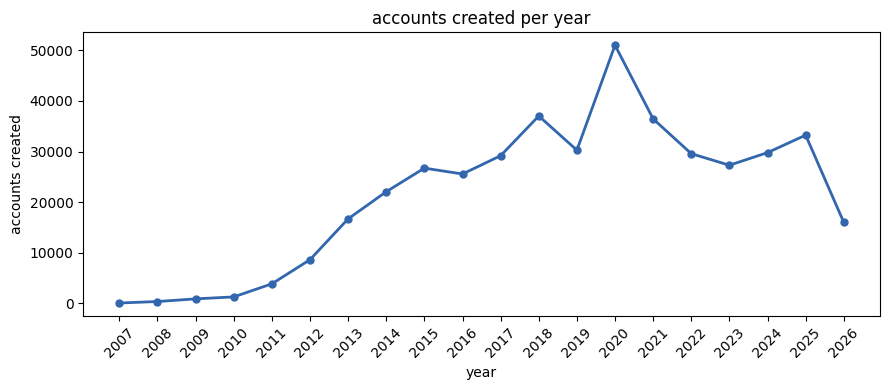

In [79]:
pdf = pdf.dropna(subset=["year"])
pdf["year"] = pdf["year"].astype(int)
plt.figure(figsize=(9, 4))
plt.plot(pdf["year"], pdf["count"], marker="o", color="#3266ad", linewidth=2, markersize=5)
plt.xticks(pdf["year"], rotation=45)
plt.xlabel("year")
plt.ylabel("accounts created")
plt.title("accounts created per year")
plt.tight_layout()
plt.show()

In [85]:
pdf = users_df.groupBy("broadcaster_type").count().orderBy("count", ascending=False).toPandas()

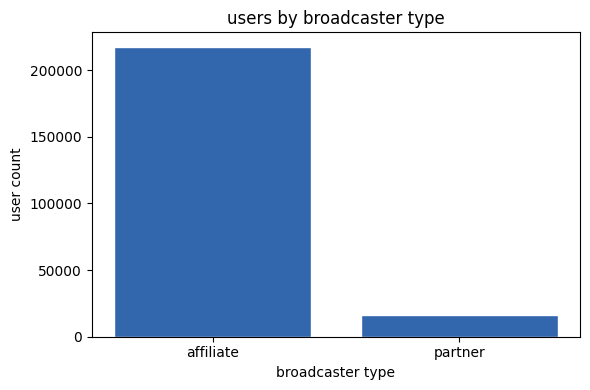

In [87]:
pdf = pdf.dropna(subset=["broadcaster_type"])
plt.figure(figsize=(6, 4))
plt.bar(pdf["broadcaster_type"], pdf["count"], color="#3266ad", edgecolor="white")
plt.xlabel("broadcaster type")
plt.ylabel("user count")
plt.title("users by broadcaster type")
plt.tight_layout()
plt.show()

In [95]:
users_df.unpersist()

DataFrame[id: string, name: string, box_art_url: string, igdb_id: string]

# Top games data

In [106]:
top_games_df=spark.read.option("header", "true").option("quote", '"') .option("escape", '"') .option("multiLine", "true") .csv("/content/top_games.csv")

In [107]:
top_games_df.show()

+----------+--------------------+--------------------+-------+
|        id|                name|         box_art_url|igdb_id|
+----------+--------------------+--------------------+-------+
|    509658|       Just Chatting|https://static-cd...|   NULL|
|     21779|   League of Legends|https://static-cd...|    115|
|    516575|            VALORANT|https://static-cd...| 126459|
|    515025|           Overwatch|https://static-cd...| 125174|
|    518018|            PRAGMATA|https://static-cd...| 134612|
|    263490|                Rust|https://static-cd...|   3277|
|    509672|                 IRL|https://static-cd...|   NULL|
|     32399|      Counter-Strike|https://static-cd...|   NULL|
|     32982|  Grand Theft Auto V|https://static-cd...|   1020|
|     27471|           Minecraft|https://static-cd...| 135400|
|     33214|            Fortnite|https://static-cd...|   1905|
|     29595|              Dota 2|https://static-cd...|   NULL|
|    499973|           Always On|https://static-cd...| 

In [108]:
top_games_df=top_games_df.drop('box_art_url')

In [109]:
top_games_df.printSchema()

root
 |-- id: string (nullable = true)
 |-- name: string (nullable = true)
 |-- igdb_id: string (nullable = true)

